**Importing Packages**

In [23]:
# ------------------------------------------------------------------------------
# Setup and Environment Configuration
# ------------------------------------------------------------------------------

import os
import time
import absl.logging
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import backend as K
from keras.initializers import Constant
from keras.utils import plot_model
from sklearn.model_selection import train_test_split

absl.logging.set_verbosity(absl.logging.INFO)

# Disable oneDNN optimizations for reproducibility/debugging
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

# ------------------------------------------------------------------------------
# Configure GPU Memory Limit
# ------------------------------------------------------------------------------

gpus = tf.config.experimental.list_physical_devices("GPU")
if gpus:
    try:
        tf.config.experimental.set_virtual_device_configuration(
            gpus[0],
            [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=15000)]
        )
    except RuntimeError as e:
        print("GPU Configuration Error:", e)

# ------------------------------------------------------------------------------
# Keras Model Building Imports
# ------------------------------------------------------------------------------

from keras.models import Sequential, Model
from keras import Input, layers, optimizers, regularizers
from keras.layers import (
    Dense, Dropout, Flatten, Reshape, Lambda,
    BatchNormalization, LayerNormalization, GlobalAveragePooling1D,
    Conv2D, Conv2DTranspose, MaxPooling2D,
    GRU, LSTM, Add, Concatenate, 
    LeakyReLU, ELU, PReLU, MultiHeadAttention
)

%autosave 180


Autosaving every 180 seconds


ImportError: attempted relative import with no known parent package

In [26]:
from plotting_utils import set_clean_style

**Pruned Dataset Processing**

Loading dataset

In [39]:
fdX_train = np.load("../data/processed/fdX_train.npy")
fdX_test = np.load("../data/processed/fdX_test.npy")
fdX_valid = np.load("../data/processed/fdX_valid.npy")
fdY_train = np.load("../data/processed/fdY_train.npy")
fdY_test = np.load("../data/processed/fdY_test.npy")
fdY_valid = np.load("../data/processed/fdY_valid.npy")
delF = np.load("../data/processed/delF.npy")
print(f"shape of fdX_train is {fdX_train.shape}")
print(f"shape of fdX_test is {fdX_test.shape}")
print(f"shape of fdX_valid is {fdX_valid.shape}")
print(f"shape of fdY_train is {fdY_train.shape}")
print(f"shape of fdY_test is {fdY_test.shape}")
print(f"shape of fdY_valid is {fdY_valid.shape}")

shape of fdX_train is (5797, 440)
shape of fdX_test is (828, 440)
shape of fdX_valid is (1656, 440)
shape of fdY_train is (5797, 100)
shape of fdY_test is (828, 100)
shape of fdY_valid is (1656, 100)


Custom Callbacks and Loss Functions

In [3]:
class CustomCallback(tf.keras.callbacks.Callback):
    loss_metric = ""
    val = 0.0

    def __init__(self, loss_metric, val):
        self.loss_metric = loss_metric
        self.val = val

    def on_epoch_end(self, epoch, logs=None):
        if logs.get(self.loss_metric) <= self.val:
            self.model.stop_training = True  # Early stopping callbacks


# Alternative
# early_stop = EarlyStopping(monitor="loss", patience=3, min_delta=0.05, restore_best_weights=True)

In [4]:
from timeit import default_timer as timer

class LogsCallback(tf.keras.callbacks.Callback):
    def __init__(self, skip_epochs, monitor=["val_mae", "val_mse"]):
        """
        Args:
            skip_epochs: Print stats every this many epochs
            monitor: List of metrics to monitor (e.g., ["val_mae", "val_mse"])
                     If None, will print all available metrics in logs
        """
        super().__init__()
        self.skip_epochs = skip_epochs
        self.epoch = 0
        self.start_time = 0.0
        self.time_block_duration = "0 sec"
        self.monitor = monitor if monitor is not None else []

    def on_train_begin(self, logs=None):
        self.start_time = timer()

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch = epoch

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.skip_epochs == 0:
            # Calculate time duration
            current_time = timer()
            elapsed_sec = int((current_time - self.start_time) % 60)
            elapsed_min = int((current_time - self.start_time) / 60.0)
            self.time_block_duration = f"{elapsed_min}min {elapsed_sec}sec"
            
            # Prepare output string
            output_parts = [f"Epoch: {epoch}"]
            
            # Add all monitored metrics or all available metrics if none specified
            metrics_to_show = self.monitor if self.monitor else logs.keys()
            
            for metric in metrics_to_show:
                if metric in logs:
                    output_parts.append(f"{metric}: {logs[metric]:.4f}")
            
            # Add timing information
            output_parts.append(f"Time for {self.skip_epochs} epochs: {self.time_block_duration}")
            
            # Print the formatted output
            print("\t".join(output_parts))
            
            # Reset timer for next block
            self.start_time = timer()

class LogsCallbackflex(tf.keras.callbacks.Callback):
    def __init__(self, skip_epochs=10, log_items=None):

        super().__init__()
        self.skipsteps = skip_epochs
        self.log_items = log_items if log_items is not None else ["loss", "val_loss"]
        self.epoch = 0
        self.starttime = 0.0
        self.endtime = 0.0
        self.timebd = "0 sec"

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch = epoch

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.skipsteps == 0:
            if epoch != 0:
                self.endtime = timer()
                self.timesec = int((self.endtime - self.starttime) % 60)
                self.timemin = int((self.endtime - self.starttime) / 60.0)
                self.timebd = f"{self.timemin}min. {self.timesec}sec."
            log_str = f"\033[1;94mEpoch: {self.epoch}\033[0m"
            for item in self.log_items:
                value = logs.get(item, None)
                if value is not None:
                    log_str += f", \t{item}: \033[92m{value:.4f}\033[0m"
            log_str += f", \ttime for prev. {self.skipsteps} epochs: \033[93m{self.timebd}\033[0m"
            print(log_str)
            self.starttime = timer()

In [5]:
def lr_scheduler(epoch, lr):
    lr = 0.00001
    if epoch > 10000:
        if (epoch % 1000) == 0:
            vb = int(epoch / 1000)
            lr = 0.00001 / (vb + 1.0)
    return lr

**Setting up TensorBoard**

In [6]:
import os

root_logdir = os.path.join(os.curdir, "tensorboard_log")


def get_run_logdir():
    import time

    run_id = time.strftime("run_%Y_%m_%d_%H_%M_%S")
    return os.path.join(root_logdir, run_id)


run_logdir = get_run_logdir()
tensorboard_cb = keras.callbacks.TensorBoard(
    run_logdir, histogram_freq=1, write_graph=True, write_images=True
)
!kill $(lsof -t -i:8083)
%reload_ext tensorboard
%tensorboard --logdir tensorboard_log --host localhost --port 8083

zsh:kill:1: not enough arguments


**Model Architectures**

### $\qquad\qquad\qquad\qquad\qquad\rightarrow$<span style="color:crimson;font-weight:bold">**Forward DNN-network**</span>$\leftarrow$
**Forward NN (State ---> Free Energy Profile)** Multidimensional input (440) ---> Multidimensional output (100)

In [7]:
def build_DNN_forward_model(
    input_shape=(440,),
    act_alpha=0.1,
    lambtha=10**-2.449,
    ad_alpha=0.001,
    ad_beta1=0.96,
    ad_beta2=0.99,
    loss_function="mae",
):

    l2_reg = [1e-06, 1e-06, 0.0000288015]
    num_neuron = [368, 248, 141]
    dropout_frac = [0.0, 0.1, 0.1]

    # Regularization
    kernel_regularizer = regularizers.l2(lambtha)
    bias_regularizer = regularizers.l2(lambtha)
    kernel_initializer = keras.initializers.he_normal(seed=40)
    bias_initializer = keras.initializers.zeros()

    optimizer = optimizers.Nadam(learning_rate=ad_alpha)

    # Activation
    activation_function = LeakyReLU(negative_slope=act_alpha)

    # Layers
    forward_input = Input(shape=(440,), name="A1")  # ,  activation=activation_function
    A2 = Dense(num_neuron[0],name="A2",
        kernel_regularizer=keras.regularizers.l2(l2_reg[0]),
        kernel_initializer=kernel_initializer,
        bias_initializer=bias_initializer)(forward_input)

    A2 = LeakyReLU(negative_slope=act_alpha)(A2)

    # dropout0 = Dropout(dropout_frac[0])(A2)  # dropout commented as dropout fraction for this layer is zero and line is redundant

    A3 = Dense(
        num_neuron[1],
        name="A3",
        kernel_regularizer=keras.regularizers.l2(l2_reg[1]),
        kernel_initializer=kernel_initializer,
        bias_initializer=bias_initializer,
    )(A2)
    A3 = LeakyReLU(negative_slope=act_alpha)(A3)
    dropout1 = Dropout(dropout_frac[1])(A3)

    A4 = Dense(
        num_neuron[2],
        name="A4",
        kernel_regularizer=keras.regularizers.l2(l2_reg[2]),
        kernel_initializer=kernel_initializer,
        bias_initializer=bias_initializer,
    )(dropout1)
    A4 = LeakyReLU(negative_slope=act_alpha)(A4)
    dropout2 = Dropout(dropout_frac[2])(A4)

    A5 = Dense(100, name="A5")(dropout2)

    model = keras.Model(forward_input, A5)

    model.compile(optimizer=optimizer, loss=loss_function, metrics=["mae", "mse"])

    return model

### $\qquad\qquad\qquad\qquad\qquad\rightarrow$<span style="color:crimson;font-weight:bold">**Building Hybrid architecture for Forward model**</span>$\leftarrow$

In [8]:
def transformer_block(polymer, surface, num_heads=2, ff_dim=64, dropout=0.1):
    # Normalize
    norm_query = LayerNormalization(epsilon=1e-6)(polymer)
    norm_keyval = LayerNormalization(epsilon=1e-6)(surface)

    # Attention: query=polymer, key/value=surface
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=ff_dim)(
        query=norm_query, key=norm_keyval, value=norm_keyval
    )
    attn_output = Dropout(dropout)(attn_output)
    out1 = Add()([polymer, attn_output])

    # Feedforward part
    x = LayerNormalization(epsilon=1e-6)(out1)
    x = Dense(ff_dim, activation="relu")(x)
    x = Dense(polymer.shape[-1])(x)
    x = Dropout(dropout)(x)
    return Add()([out1, x])

def expand_surface_sequence_fn(x):
    return tf.tile(tf.expand_dims(x, axis=1), [1, 40, 1])

def slice_surface_fn(x):
    return x[:, :400]

def slice_polymer_fn(x):
    return x[:, 400:]


def build_HybridCNN_forward_model():
    kernel_initializer = keras.initializers.he_normal(seed=40)

    input_seq = Input(shape=(440,), name="seq_input")

    # Split surface and polymer
    surface = Lambda(slice_surface_fn, name="lambda_surface_slice")(input_seq)
    polymer = Lambda(slice_polymer_fn, name="lambda_polymer_slice")(input_seq)

    surface = Reshape((20, 20, 1))(surface)  # (None, 20, 20, 1)
    polymer = Reshape((40, 1))(polymer)  # (None, 40, 1)

    # CNN for surface
    x_surface = Conv2D(32, (3, 3), activation="relu", padding="same")(surface)
    x_surface = MaxPooling2D((2, 2))(x_surface)
    x_surface = Conv2D(64, (3, 3), activation="relu", padding="same")(x_surface)
    x_surface = MaxPooling2D((2, 2))(x_surface)
    x_surface = Conv2D(128, (3, 3), activation="relu", padding="same")(x_surface)
    x_surface = Flatten()(x_surface)
    
    surface_proj = Dense(64, activation="relu")(x_surface)  # (None, 64)

    # Expand surface to sequence: (None, 40, features)
    surface_seq = Lambda(expand_surface_sequence_fn, name="lambda_expand_surface_sequence")(surface_proj)

    # Polymer encoding with GRU
    x_polymer = GRU(64, return_sequences=True)(polymer)  # (None, 40, 64)
    x_polymer = LayerNormalization()(x_polymer)

    # Apply Transformer block between polymer as query & surface as key, values
    x_trans = transformer_block(x_polymer, surface_seq)

    # Pooling + Dense
    x = Flatten()(x_trans)
    # x = GlobalAveragePooling1D()(x_trans)
    x = Dropout(0.2)(x)
    x = Dense(250, kernel_initializer=kernel_initializer)(x)
    x = LeakyReLU()(x)
    x = Dense(140, kernel_initializer=kernel_initializer, kernel_regularizer=keras.regularizers.l2(1e-6))(x)
    x = LeakyReLU()(x)
    # x = Dropout(0.1)(x)
    x = Dense(100, name="pmf_output")(x)

    model = Model(inputs=input_seq, outputs=x, name="PolymerSurfaceTransformer")

    model.compile(optimizer=optimizers.Nadam(learning_rate=0.0001, beta_1=0.97, beta_2=0.97), loss="mae", metrics=["mae", "mse"])

    return model

In [9]:
neural_tag = "canonical"
model_variants = ["DNN", "HybridCNN"]
NN_type = "HybridCNN"
# Check for validity of NN_type
assert (
    NN_type in model_variants
), f"Variant '{i}' not supported. Please check the variant again!"

$\rightarrow$<span style="color:blue">Building Forward Model</span>

In [10]:
# Choice of parameters and functions based on NN type
if NN_type == "DNN":
    forwardModel = build_DNN_forward_model()
    epochs = 3000

elif NN_type == "HybridCNN":
    forwardModel = build_HybridCNN_forward_model()
    epochs = 2000

# Model summary
forwardModel.summary()

Model: "PolymerSurfaceTransformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 440)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_surface_sli… │ (None, 400)       │          0 │ seq_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 20, 20, 1) │          0 │ lambda_surface_s… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 20, 20,    │        320 │ reshape[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 10, 10,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 10, 10,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 5, 5, 64)  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_polymer_sli… │ (None, 40)        │          0 │ seq_input[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 5, 5, 128) │     73,856 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 40, 1)     │          0 │ lambda_polymer_s… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3200)      │          0 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 40, 64)    │     12,864 │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │    204,864 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 40, 64)    │        128 │ gru[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_expand_surf… │ (None, 40, 64)    │          0 │ dense[0][0]       │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 40, 64)    │        128 │ lambda_expand_su… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 40, 64)    │        128 │ layer_normalizat… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 40, 64)    │     33,216 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,041,938 (3.97 MB)

 Trainable params: 1,041,938 (3.97 MB)

 Non-trainable params: 0 (0.00 B)

$\rightarrow$<span style="color:blue">Training Forward Model</span>  
Skip this cell if the model has already been trained. Proceed to the next step to load the saved model directly.

In [11]:

# logs_cb = LogsCallback(skip_epochs = 50)
# checkpoint_cb = keras.callbacks.ModelCheckpoint(f"scratch_alen/final/checkpoint/{NN_type}/{neural_tag}_forward_model.keras",monitor='val_mae',
#                                                 save_best_only=True,save_weights_only=False,mode="auto")
# reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=100, min_lr=1e-5, verbose=1)

# # Training
# start_time = time.time()
# forward_history = forwardModel.fit(fdX_train, fdY_train, batch_size=64, epochs=epochs, verbose=0, validation_data = (fdX_valid, fdY_valid),
#                            callbacks=[checkpoint_cb, logs_cb, reduce_lr])
# end_time = time.time()
# total_time = [int((end_time - start_time)/3600), int(((end_time - start_time)/60)%60), int(end_time - start_time)%60]
# print(f"Total training time: {total_time[0]}h, {total_time[1]}m, {total_time[2]} s")

# # Save endpoint model and training history
# np.save(f"scratch_alen/final/history/{NN_type}/{neural_tag}_forward_history.npy",forward_history.history)
# forwardModel.save(f"scratch_alen/final/model_end/{NN_type}/{neural_tag}_forward_model.keras")

$\rightarrow$<span style="color:cyan">**Loading forward model's histories and best model**</span>

In [12]:
##### Loading model after training #########
if NN_type == "DNN":
    custom_objects = {}
elif NN_type == "HybridCNN":
    custom_objects = {
    "slice_surface_fn": slice_surface_fn,  # Must match Lambda layer name
    "slice_polymer_fn": slice_polymer_fn,
    "expand_surface_sequence_fn": expand_surface_sequence_fn
}
forwardModel = keras.models.load_model(
    f"checkpoint/{NN_type}/{neural_tag}_forward_model.keras",
    custom_objects=custom_objects)
forward_history = np.load(
    f"history/{NN_type}/{neural_tag}_forward_history.npy",
    allow_pickle="TRUE").item()

$\rightarrow$<span style="color:blue">Building Backward Model</span>

Training History

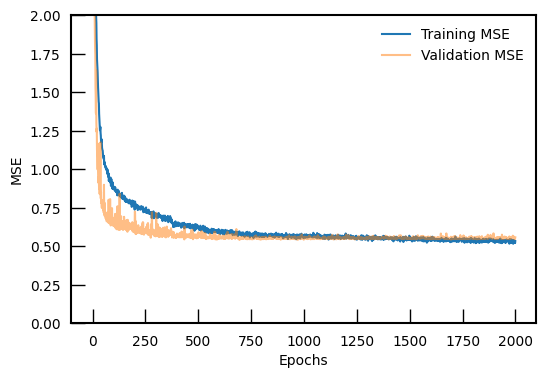

In [13]:
plt.figure(figsize=(6, 4))
plt.plot(forward_history["mse"][:], label="Training MSE")
plt.plot(forward_history["val_mse"][:], label="Validation MSE", alpha=0.5)
plt.xlabel("Epochs")
plt.ylabel("MSE")

plt.gca().set_ylim(0.0, 2)
ax = plt.gca()

ax.tick_params(
    axis="both",
    direction="in",
    length=10,
    width=1,
    colors="black",
    pad=8,
    which="major",
)
ax.tick_params(
    axis="both", direction="in", length=5, width=1, colors="black", pad=8, which="minor"
)
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
plt.legend(loc=1, fontsize=10, framealpha=0)
plt.show()
# plt.savefig("scratch_alen/plots/DNN/" + neural_tag + "_forward_mse.pdf", dpi=300)

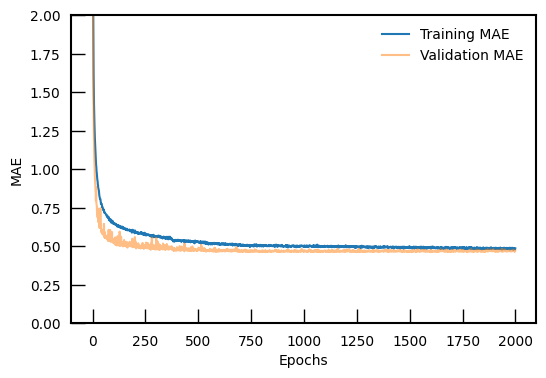

In [14]:
plt.figure(figsize=(6, 4))
plt.plot(forward_history["mae"][:], label="Training MAE")
plt.plot(forward_history["val_mae"][:], label="Validation MAE", alpha=0.5)
plt.xlabel("Epochs")
plt.ylabel("MAE")

plt.gca().set_ylim(0.0, 2)
ax = plt.gca()

ax.tick_params(
    axis="both",
    direction="in",
    length=10,
    width=1,
    colors="black",
    pad=8,
    which="major",
)
ax.tick_params(
    axis="both", direction="in", length=5, width=1, colors="black", pad=8, which="minor"
)
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
plt.legend(loc=1, fontsize=10, framealpha=0)
plt.show()
# plt.savefig("scratch_alen/plots/DNN/" + neural_tag + "_forward_mae.pdf", dpi=300)

In [15]:
plt.figure(figsize=(6, 4))
plt.plot(tandem_history["mse"][:], label="Training MSE")
plt.plot(tandem_history["val_mse"][:], label="Validation MSE", alpha=0.5)
plt.xlabel("Epochs")
plt.ylabel("MSE")

plt.gca().set_ylim(0.0, 10)
ax = plt.gca()
# ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
# ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
# ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
# ax.yaxis.set_minor_locator(ticker.MultipleLocator(2))

ax.tick_params(
    axis="both",
    direction="in",
    length=10,
    width=1,
    colors="black",
    pad=8,
    which="major",
)
ax.tick_params(
    axis="both", direction="in", length=5, width=1, colors="black", pad=8, which="minor"
)
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
plt.legend(loc=1, fontsize=10, framealpha=0)
# plt.show()
plt.savefig("scratch_alen/plots/DNN/" + neural_tag + "_tandem_mse.pdf", dpi=300)

NameError: name 'tandem_history' is not defined

<Figure size 600x400 with 0 Axes>

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(tandem_history["mae"][:], label="Training MAE")
plt.plot(tandem_history["val_mae"][:], label="Validation MAE", alpha=0.5)
plt.xlabel("Epochs")
plt.ylabel("MAE")

ax = plt.gca()

# ax.set_xlim(0.0,1000)
# ax.set_ylim(0.0,1000)
# ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
# ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
# ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
# ax.yaxis.set_minor_locator(ticker.MultipleLocator(2))

ax.tick_params(
    axis="both",
    direction="in",
    length=10,
    width=1,
    colors="black",
    pad=8,
    which="major",
)
ax.tick_params(
    axis="both", direction="in", length=5, width=1, colors="black", pad=8, which="minor"
)
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
plt.legend(loc=1, fontsize=10, framealpha=0)
# plt.show()
plt.savefig("scratch_alen/plots/DNN/" + neural_tag + "_tandem_mae.pdf", dpi=300)

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(extend_history["mse"][:], label="Training MSE")
plt.plot(extend_history["val_mse"][:], label="Validation MSE", alpha=0.5)
plt.xlabel("Epochs")
plt.ylabel("MSE")

# plt.gca().set_ylim(0.0,2)
ax = plt.gca()
# ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
# ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
# ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
# ax.yaxis.set_minor_locator(ticker.MultipleLocator(2))

ax.tick_params(
    axis="both",
    direction="in",
    length=10,
    width=1,
    colors="black",
    pad=8,
    which="major",
)
ax.tick_params(
    axis="both", direction="in", length=5, width=1, colors="black", pad=8, which="minor"
)
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
plt.legend(loc=1, fontsize=10, framealpha=0)
# plt.show()
plt.savefig("scratch_alen/plots/DNN/" + neural_tag + "_extend_mse.pdf", dpi=300)

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(extend_history["mae"][:], label="Training MAE")
plt.plot(extend_history["val_mae"][:], label="Validation MAE", alpha=0.5)
plt.xlabel("Epochs")
plt.ylabel("MAE")

ax = plt.gca()

# ax.set_xlim(0.0,1000)
ax.set_ylim(0.0, 4.0)
# ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
# ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
# ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
# ax.yaxis.set_minor_locator(ticker.MultipleLocator(2))

ax.tick_params(
    axis="both",
    direction="in",
    length=10,
    width=1,
    colors="black",
    pad=8,
    which="major",
)
ax.tick_params(
    axis="both", direction="in", length=5, width=1, colors="black", pad=8, which="minor"
)
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
plt.legend(loc=1, fontsize=10, framealpha=0)
# plt.show()
plt.savefig("scratch_alen/plots/DNN/" + neural_tag + "_extend_mae.pdf", dpi=300)

In [ ]:
# scores = forwardModel.evaluate(x_test, y_test)

Comparing models

In [ ]:
# print("Minimum val. MAE of canonical model: ", min(hist_canonical['val_mae']))
# print("Minimum val. MAE of augmented model: ", min(hist_augmented['val_mae']))

In [ ]:
model_types = ["canonical", "augmented", "mixed"]
network_types = ["forward", "tandem", "extend"]
colors = {"canonical": "red", "augmented": "blue", "mixed": "green"}

for network_type in network_types:
    plt.figure(figsize=(6, 4))
    plt.xlabel("Epochs")
    plt.ylabel("MAE")

    for model_type in model_types:
        history_path = (
            f"scratch_alen/history/DNN/{model_type}_{network_type}_history.npy"
        )
        history = np.load(history_path, allow_pickle=True).item()

        # Training MAE
        plt.plot(
            history["mae"][100:],
            label=f"{model_type} - Training",
            color=colors[model_type],
        )
        # Validation MAE
        plt.plot(
            history["val_mae"][100:],
            label=f"{model_type} - Validation",
            linestyle="--",
            color=colors[model_type],
            alpha=0.6,
        )

    ax = plt.gca()
    ax.tick_params(
        axis="both",
        direction="in",
        length=10,
        width=1,
        colors="black",
        pad=8,
        which="major",
    )
    ax.tick_params(
        axis="both",
        direction="in",
        length=5,
        width=1,
        colors="black",
        pad=8,
        which="minor",
    )
    ax.spines["bottom"].set_linewidth(1.5)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["top"].set_linewidth(1.5)
    ax.spines["right"].set_linewidth(1.5)

    plt.legend(loc=1, fontsize=10, framealpha=0)
    plt.tight_layout()

    # Save each figure with network_type in filename
    plt.savefig(f"scratch_alen/plots/DNN/combined_{network_type}_mae.pdf", dpi=300)
    plt.close()

In [ ]:
model_types = ["canonical", "augmented", "mixed"]
network_types = ["forward", "tandem", "extend"]
colors = {"canonical": "red", "augmented": "blue", "mixed": "green"}

for network_type in network_types:
    plt.figure(figsize=(6, 4))
    plt.xlabel("Epochs")
    plt.ylabel("MSE")

    for model_type in model_types:
        history_path = (
            f"scratch_alen/history/DNN/{model_type}_{network_type}_history.npy"
        )
        history = np.load(history_path, allow_pickle=True).item()

        # Training MSE
        plt.plot(
            history["mse"][100:],
            label=f"{model_type} - Training",
            color=colors[model_type],
        )
        # Validation MSE
        plt.plot(
            history["val_mse"][100:],
            label=f"{model_type} - Validation",
            linestyle="--",
            color=colors[model_type],
            alpha=0.6,
        )

    ax = plt.gca()
    ax.tick_params(
        axis="both",
        direction="in",
        length=10,
        width=1,
        colors="black",
        pad=8,
        which="major",
    )
    ax.tick_params(
        axis="both",
        direction="in",
        length=5,
        width=1,
        colors="black",
        pad=8,
        which="minor",
    )
    ax.spines["bottom"].set_linewidth(1.5)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["top"].set_linewidth(1.5)
    ax.spines["right"].set_linewidth(1.5)

    plt.legend(loc=1, fontsize=10, framealpha=0)
    plt.tight_layout()

    # Save each figure with network_type in filename
    plt.savefig(f"scratch_alen/plots/DNN/combined_{network_type}_mse.pdf", dpi=300)
    plt.close()

In [ ]:
testmodel = build_HybridCNN_backward_model(learning_rate=0.001)
logs_cb_mod = LogsCallbackflex(skip_epochs=50, log_items=["loss", "val_loss"])
update_cb = UpdateSharpnessCallback(surf_activation_layer)
# for layer in testmodel.layers:
#     if "poly" in layer.name:
#         layer.trainable = False
testmodel.summary()
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=100, min_lr=1e-5, verbose=1
)
# Training
# surface_labels = fdX_train[:,:400]
# polymer_labels =  fdX_train[:,400:]
# surface_valid = fdX_valid[:,:400]
# polymer_valid =  fdX_valid[:,400:]
start_time = time.time()
test_history = testmodel.fit(
    fdY_train,
    fdX_train,
    batch_size=64,
    epochs=1000,
    verbose=0,
    validation_data=(fdY_valid, fdX_valid),
    callbacks=[logs_cb_mod, reduce_lr, update_cb],
)
end_time = time.time()
total_time = [
    int((end_time - start_time) / 3600),
    int(((end_time - start_time) / 60) % 60),
    int(end_time - start_time) % 60,
]
print(f"Total training time: {total_time[0]}h, {total_time[1]}m, {total_time[2]} s")
# testmodel.output_names

In [ ]:
# Step 1: Build full model
model = build_HybridCNN_backward_model()  # everything trainable

# Step 2: Freeze surface → train polymer
for layer in model.layers:
    if "surf_" in layer.name:
        layer.trainable = False
model.compile(
    optimizer=keras.optimizers.Nadam(learning_rate=1e-4),
    loss={
        "surface_output": keras.losses.BinaryFocalCrossentropy(alpha=0.75, gamma=2.0),
        "polymer_output": keras.losses.BinaryFocalCrossentropy(alpha=0.75, gamma=2.0),
    },
    loss_weights={"surface_output": 0.0, "polymer_output": 1.0},
    metrics={
        "surface_output": ["binary_accuracy"],
        "polymer_output": ["binary_accuracy"],
    },
)
model.fit(
    x=fdY_train,
    y={"surface_output": surface_labels, "polymer_output": polymer_labels},
    batch_size=64,
    epochs=1000,
    verbose=0,
    validation_data=(
        fdY_valid,
        {"surface_output": surface_valid, "polymer_output": polymer_valid},
    ),
    callbacks=[logs_cb_mod, reduce_lr],
)  # Train only polymer

# Step 3: Freeze polymer → train surface
for layer in model.layers:
    if "poly_layer" in layer.name:
        layer.trainable = False
    elif "surf_" in layer.name:
        layer.trainable = True
model.compile(
    optimizer=keras.optimizers.Nadam(learning_rate=1e-4),
    loss={
        "surface_output": keras.losses.BinaryFocalCrossentropy(alpha=0.75, gamma=2.0),
        "polymer_output": keras.losses.BinaryFocalCrossentropy(alpha=0.75, gamma=2.0),
    },
    loss_weights={"surface_output": 1.0, "polymer_output": 0.0},
    metrics={
        "surface_output": ["binary_accuracy"],
        "polymer_output": ["binary_accuracy"],
    },
)
model.fit(
    x=fdY_train,
    y={"surface_output": surface_labels, "polymer_output": polymer_labels},
    batch_size=64,
    epochs=1000,
    verbose=0,
    validation_data=(
        fdY_valid,
        {"surface_output": surface_valid, "polymer_output": polymer_valid},
    ),
    callbacks=[logs_cb_mod, reduce_lr],
)  # Train only surface

# Step 4: Unfreeze everything and fine-tune
for layer in model.layers:
    layer.trainable = True
model.compile(
    optimizer=keras.optimizers.Nadam(learning_rate=1e-5),  # lower LR for fine-tuning
    loss={
        "surface_output": keras.losses.BinaryFocalCrossentropy(alpha=0.75, gamma=2.0),
        "polymer_output": keras.losses.BinaryFocalCrossentropy(alpha=0.75, gamma=2.0),
    },
    loss_weights={"surface_output": 1.0, "polymer_output": 0.1},
    metrics={
        "surface_output": ["binary_accuracy"],
        "polymer_output": ["binary_accuracy"],
    },
)
model.fit(
    x=fdY_train,
    y={"surface_output": surface_labels, "polymer_output": polymer_labels},
    batch_size=64,
    epochs=1000,
    verbose=0,
    validation_data=(
        fdY_valid,
        {"surface_output": surface_valid, "polymer_output": polymer_valid},
    ),
    callbacks=[logs_cb_mod, reduce_lr],
)

In [ ]:
model_CNN = keras.models.load_model(f"scratch_alen/final/model_end/HybridCNN/canonical_forward_model.keras",custom_objects={'expand_surface_sequence': expand_surface_sequence,'slice_surface': slice_surface,
     'slice_polymer': slice_polymer})

In [ ]:
model_DNN = keras.models.load_model(f"scratch_alen/final/model_end/DNN/canonical_forward_model.keras")

### Evaluate forward model- figure-6, figure SI.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score,mean_squared_error
from sklearn.linear_model import LinearRegression

def evaluate_forward_model_performance(
    y_true, y_pred,
    y_true_train=None, y_pred_train=None,
    plot_scatter=True,
    compute_sliding=False,
    window_size=10,
    num_scatter_points=100,save_path=None,use_delf=False
):
    """
    Evaluate forward model prediction performance.
    
    Args:
        y_true: [n_test, 100] PMF bins, test set ground truth
        y_pred: [n_test, 100] PMF bins, test set predictions
        y_true_train, y_pred_train: optional train set ground truth/pred
        plot_scatter: show 2D scatter plot with random samples
        compute_sliding: compute MAE/R² over sliding window
        window_size: size of the bin window for local MAE/R²
        num_scatter_points: how many test/train points to plot

    Returns:
        result_dict: {
            'r2_test', 'mae_test', 'r2_train', 'mae_train',
            'mae_per_window', 'r2_per_window'
        }
    """
    result = {}
    # y_true_flat = y_true
    # y_pred_flat = y_pred
    
    # result['r2_test'] = r2_score(y_true_flat, y_pred_flat)
    # result['mae_test'] = mean_absolute_error(y_true_flat, y_pred_flat)

    # # if y_true_train is not None and y_pred_train is not None:
    # y_true_train_flat = y_true_train
    # y_pred_train_flat = y_pred_train
    # result['r2_train'] = r2_score(y_true_train_flat, y_pred_train_flat)
    # result['mae_train'] = mean_absolute_error(y_true_train_flat, y_pred_train_flat)
    # else:
    #     result['r2_train'] = result['mae_train'] = None
    if use_delf:
            # Compute ΔF for test and train
            y_true_flat = np.mean(y_true[:, 90:], axis=1) - np.min(y_true, axis=1)
            y_pred_flat = np.mean(y_pred[:, 90:], axis=1) - np.min(y_pred, axis=1)
        
            result['r2_test'] = r2_score(y_true_flat, y_pred_flat)
            result['mae_test'] = mean_absolute_error(y_true_flat, y_pred_flat)
        
            if y_true_train is not None and y_pred_train is not None:
                y_true_train_flat = np.mean(y_true_train[:, 90:], axis=1) - np.min(y_true_train, axis=1)
                y_pred_train_flat = np.mean(y_pred_train[:, 90:], axis=1) - np.min(y_pred_train, axis=1)
        
                result['r2_train'] = r2_score(y_true_train_flat, y_pred_train_flat)
                result['mae_train'] = mean_absolute_error(y_true_train_flat, y_pred_train_flat)
            else:
                result['r2_train'] = result['mae_train'] = None

    else:
        y_true_flat = y_true
        y_pred_flat = y_pred
        result['r2_test'] = r2_score(y_true_flat, y_pred_flat)
        result['mae_test'] = mean_absolute_error(y_true_flat, y_pred_flat)
    
        if y_true_train is not None and y_pred_train is not None:
            y_true_train_flat = y_true_train
            y_pred_train_flat = y_pred_train
            result['r2_train'] = r2_score(y_true_train_flat, y_pred_train_flat)
            result['mae_train'] = mean_absolute_error(y_true_train_flat, y_pred_train_flat)
        else:
            result['r2_train'] = result['mae_train'] = None

    if compute_sliding and not use_delf:
        n_bins = y_true.shape[1]
        r2_per_window = []
        mae_per_window = []
        for i in range(0, n_bins, window_size):
            y_true_win = y_true[:, i:i+window_size]
            y_pred_win = y_pred[:, i:i+window_size]
            r2 = r2_score(y_true_win.flatten(), y_pred_win.flatten())
            mae = mean_absolute_error(y_true_win.flatten(), y_pred_win.flatten())
            r2_per_window.append(r2)
            mae_per_window.append(mae)
        result['r2_per_window'] = np.array(r2_per_window)
        result['mae_per_window'] = np.array(mae_per_window)
    
    if plot_scatter:
        test_indices = np.random.choice(len(y_true_flat), size=num_scatter_points, replace=False)
        x_test_sample = y_true_flat[test_indices].flatten()
        y_test_sample = y_pred_flat[test_indices].flatten()

        reg = LinearRegression().fit(x_test_sample.reshape(-1, 1), y_test_sample)
        y_fit = reg.predict(np.sort(x_test_sample).reshape(-1, 1))

        if y_true_train is not None and y_pred_train is not None:
            y_train_flat = np.mean(y_true_train[:, 90:], axis=1) - np.min(y_true_train, axis=1)
            y_pred_train_flat = np.mean(y_pred_train[:, 90:], axis=1) - np.min(y_pred_train, axis=1)
            
            train_indices = np.random.choice(len(y_train_flat), size=num_scatter_points, replace=False)
            x_train_sample = y_train_flat[train_indices]
            y_train_sample = y_pred_train_flat[train_indices]
        plt.figure(figsize=(3, 3))
        plt.plot([0,80],[0,80],linewidth=1.5,color='red',alpha=0.8)
        plt.plot(np.sort(x_test_sample), y_fit, color='red', label='Fit')
        plt.plot([min(x_test_sample), max(x_test_sample)],
                 [min(x_test_sample), max(x_test_sample)], 'k--', linewidth=1)
        
        if y_true_train is not None:
            plt.scatter(x_train_sample, y_train_sample, alpha=0.7, s=30, color='blue', edgecolors='black',linewidths=1)
    
        plt.scatter(x_test_sample, y_test_sample, alpha=0.7, s=30, color='red', edgecolors='black',linewidths=1)


        ax = plt.gca()
        set_clean_style(ax,major_ticks_x=20,minor_ticks_x=4,major_ticks_y=20,minor_ticks_y=4,minor_tick=True)
        # ax.set_xlim(-10,100)
        # ax.set_ylim(-10,100)
        ax.set_xlabel(r"$ \Delta F_{Simulated} (k_{B}T)$")
        ax.set_ylabel(r"$ \Delta F_{ML} (k_{B}T)$")
        plt.tight_layout()
        plt.legend([fr"Train $R^{2}$: {result['r2_train']:.3f}",fr"Test $R^{2}$:{result['r2_test']:.3f}"],framealpha=0,fontsize=10)
        if save_path:
            plt.savefig(save_path, dpi=600, bbox_inches='tight',transparent=True)
        else:
            plt.show()
# : {result['r2_train']:.3f}, :{result['r2_test']:.3f}
    return result

In [35]:
# results = evaluate_forward_model_performance(
#     y_true=fdY_test,
#     y_pred=forwardModel.predict(fdX_test),
#     y_true_train=fdY_train,
#     y_pred_train=forwardModel.predict(fdX_train),
#     plot_scatter=True,
#     compute_sliding=False,
#     window_size=40,num_scatter_points=800,use_delf=True,
#     save_path=None
# )
# Plot sliding window MAE
# plt.figure(figsize=(3,2.5))
# plt.plot(results['mae_train'], marker='d', color='blue',alpha=0.8)
# ax = plt.gca()
# set_clean_style(ax,major_ticks_x=5,minor_ticks_x=1,major_ticks_y=0.2)#,minor_ticks_y=0.1,minor_tick=True)
# # ax2 = ax.twinx()
# # set_clean_style(ax2,major_ticks_x=2,minor_ticks_x=1,major_ticks_y=0.009)
# # ax2.plot(results['r2_per_window'], marker='o', color='tab:red',alpha=0.6)
# plt.xlabel("Window Index")
# plt.ylabel(r"$R^{2}$")
# # ax2.set_ylim(0.95,1)
# # ax.set_ylim(0.1,0.8)
# plt.tight_layout()
# plt.show()
# print(results['mae_train'])
# plt.savefig("plots_siba/evaluation_forward/MAE_per_window.pdf", dpi=600, bbox_inches='tight',transparent=True)
predictions = forwardModel.predict(fdX_test, verbose=1)
Y_true = fdY_test
mae = mean_absolute_error(Y_true.flatten(), predictions.flatten())
print(f"MAE: {mae:.4f}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
MAE: 0.8684


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error

def plot_residuals_histogram(y_train, y_train_pred, y_test, y_test_pred,
                              bins=40, figsize=(3, 3),
                              color_train='royalblue', color_test='crimson',
                              alpha_train=0.6, alpha_test=0.5,save_path=None
                              ):
    res_train = (y_train_pred - y_train).flatten()
    res_test = (y_test_pred - y_test).flatten()

    plt.figure(figsize=figsize)
    plt.hist(res_train, bins=bins, alpha=alpha_train, color=color_train,
             density=True,  edgecolor='black')
    plt.hist(res_test, bins=bins, alpha=alpha_test, color=color_test,
             density=True,  edgecolor='black')

    plt.xlabel(r"$F_{ML}-F_{Simulated} (k_{B}T)$")
    plt.ylabel("Density")
    plt.tight_layout()    
    ax = plt.gca()
    ax.tick_params(axis='both', direction='in', length=5, width=0.8, colors='black', pad=4, which='major')
    ax.tick_params(axis='both', direction='in', length=3, width=0.8, colors='black', pad=8, which='minor')
    # ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    # ax.yaxis.set_major_locator(ticker.MultipleLocator(1))    
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontsize(12)
        label.set_fontweight('medium')

    for spine in ax.spines.values():
        spine.set_linewidth(0.9)
    # set_clean_style(ax,major_ticks_x=1,minor_ticks_x=1,major_ticks_y=1,minor_ticks_y=0.05,minor_tick=True)
    plt.tight_layout()
    if save_path:
            plt.savefig(save_path, dpi=600, bbox_inches='tight',transparent=True)
    else:
        plt.show()


In [ ]:
plot_residuals_histogram(
    y_train=fdY_train,
    y_train_pred=model_DNN.predict(fdX_train),
    y_test=fdY_test,
    y_test_pred=model_DNN.predict(fdX_test),bins=20,save_path="plots_siba/evaluation_forward/residual_DNN_canonical.pdf"
)

In [ ]:
mean_absolute_error(delF_test,delF_pred)/np.std(delF_test)

In [ ]:
surface = fdX_test[:,:400]
polymer = fdX_test[:,400:]
surf_comp = np.round(1- np.mean(surface, axis=1),decimals=1)
poly_comp = np.round(1- np.mean(polymer,axis=1),decimals=1)
delF_pred = np.mean(y_pred[:, 90:], axis=1) - np.min(y_pred, axis=1)
delF_test = np.mean(fdY_test[:, 90:], axis=1) - np.min(fdY_test, axis=1)
delF_train = np.mean(fdY_train[:, 90:], axis=1) - np.min(fdY_train, axis=1)

In [ ]:
from scipy.stats import gaussian_kde
plt.figure(figsize=(4, 3))
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'yellow','pink', '#FF6F61',"#7AE582"]
data = delF_test.flatten()
kde = gaussian_kde(data)
x_vals = np.linspace(np.min(data), np.max(data), 1000)
plt.plot(x_vals, kde(x_vals),  color=colors[1])
plt.fill_between(x_vals, kde(x_vals),color=colors[1],alpha=0.2)
data1 = delF_train.flatten()
kde1 = gaussian_kde(data1)
x_vals1 = np.linspace(np.min(data1), np.max(data1), 1000)
plt.plot(x_vals1, kde1(x_vals1),  color=colors[2])
plt.fill_between(x_vals1, kde1(x_vals1),color=colors[5],alpha=0.1)
plt.show()

### pmf true vs predicted

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def plot_predicted_vs_true_pmf(
    y_true, y_true_all=None, x_data=None, sample_indices=None, colors=None, save_path=None   
):                                           # Include y_pred if you want to include y_pred line

    if x_data is None:
        x_data = np.linspace(0, 10, 100)
    if sample_indices is None:
        sample_indices = [0, 1, 2]

    if colors is None:
        colors = [
            "#d83034",
            "#21A685",
            "#8d1f17",
            "#ff9d3a",
            "#0b81a2",
            "#4D4D4D",
        ]

    plt.figure(figsize=(2.5, 2.5))
    if y_true_all is not None:
        for i in range(len(y_true_all)):
            color = colors[i % len(colors)]
            plt.plot(
                x_data,
                y_true_all[i],
                color=color,
                linestyle="--",
                alpha=1,
                linewidth=1,
                zorder=0
            )

    for idx, i in enumerate(sample_indices):
        color = colors[idx % len(colors)]
        plt.plot(
            x_data,
            y_true[i],
            label=f"True {i}",
            linestyle="-",
            color=color,
            linewidth=1.5,
        )
        # plt.plot(
        #     x_data,
        #     y_pred[i],
        #     label=f"Pred {i}",
        #     linestyle="--",
        #     color=color,
        #     linewidth=1.5,
        # )

    plt.xlabel(r"$Z_{cm} (\sigma)$")
    plt.ylabel(r"$F(k_B T)$")

    ax = plt.gca()
    set_clean_style(ax,major_ticks_x=2,minor_ticks_x=0.5,major_ticks_y=10,minor_ticks_y=2,minor_tick=True)
    # plt.legend(framealpha=0, fontsize=8, loc=0)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches="tight", transparent=True)
    else:
        plt.show()

In [ ]:
# index = np.random.randint(827)

plot_predicted_vs_true_pmf(
    y_true=fdY_test,
    y_pred=model_CNN.predict(fdX_test),
    x_data=None,
    sample_indices=[154,799,152,541],  #154,799,152,541(final take-up) (for strong pmf plot)418,389
    save_path="plots_siba/evaluation_forward/CNN_predicted_a.pdf"                    #578,633,504,821(for week pmf)
)
# print(f"Surface comp:{np.round(1- np.mean(fdX_test[index,:400],axis=0),decimals=1)},Polymer comp:{np.round(1- np.mean(fdX_test[index,400:],axis=0),decimals=1)}")
# # print(np.mean(fdX_test[index,:400],axis=0))
# fig, ax = plt.subplots(nrows=2, ncols=1,figsize=(8,5))
# ax = ax.flatten()
# ax[0].imshow(fdX_test[index,:400].reshape(20,20),cmap=cmap)
# ax[1].imshow(fdX_test[index,400:].reshape(1,40),cmap=cmap)
# ax[0].set_xticks(np.arange(-0.5, 20, 1), minor=True)
# ax[0].set_yticks(np.arange(-0.5, 20, 1), minor=True)
# ax[0].grid(which='minor', color='white', linestyle='-', linewidth=0.6)
# plt.show()

### Loss vs epoch plot

In [ ]:
def moving_average(data, window):
    return np.convolve(data, np.ones(window) / window, mode="valid")


def plot_history_metrics(
    history,
    metric="loss",
    data_types=("train", "val"),  # any combo: ('train',), ('val',), ('train', 'val')
    min_epoch=None,
    smooth_window=None,
    savepath=None,
    figsize=(4, 3),
):
    """
    Plot one or more metric types (e.g., train/val/test) from history.

    Parameters:
    - history: model.fit() history or dict
    - metric: base metric name, e.g. 'loss', 'mae', 'accuracy'
    - data_types: tuple of str, e.g. ('train',), ('val',), ('train','val')
    - max_epoch: int, truncate epochs
    - smooth_window: int, apply moving average
    - savepath: str, file path to save
    - figsize: tuple, default (4, 3)
    """

    if isinstance(history, dict):

        class DummyHistory:
            pass

        h = DummyHistory()
        h.history = history
        history = h

    hist = history.history
    colors = {"train": "blue", "val": "orange", "test": "green"}

    plt.figure(figsize=figsize)

    for dtype in data_types:
        key = metric if dtype == "train" else f"{dtype}_{metric}"
        if key not in hist:
            print(f" Skipping: '{key}' not found in history.")
            continue

        values = np.array(hist[key])
        epochs = np.arange(1, len(values) + 1)

        # Truncate
        if min_epoch:
            values = values[min_epoch:]/10.0
            epochs = epochs[min_epoch:]
        # plt.plot(epochs, values, lw=1.2, color=colors.get(dtype, 'green'), alpha=0.7)
        # Smooth
        if smooth_window and smooth_window < len(values):
            values = moving_average(values, smooth_window)/10.0
            epochs = epochs[: len(values)]

        label = f"{dtype.capitalize()} {metric.capitalize()}"
        plt.plot(epochs, values, lw=2, color=colors.get(dtype, None), label=label)

    plt.xlabel("Epoch", fontsize=12, fontweight="medium")
    plt.ylabel(metric.capitalize(), fontsize=12, fontweight="medium")
    # plt.legend(fontsize=10, frameon=False)

    ax = plt.gca()
    # set_clean_style(ax)
    ax.set_ylim(0, 1)
    
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=600)
    # plt.show()

In [ ]:
# forward_history_cnn = np.load("my_models_siba/history/DNN/canonical_forward_history_DNN_mod.npy",allow_pickle='TRUE').item()
# forward_history_cnn = np.load(f"scratch_alen/final/history/DNN/canonical_forward_history.npy",allow_pickle='TRUE').item()
tandem_history_cnn = np.load(
    f"scratch_alen/final/history/{NN_type}/{neural_tag}_tandem_history.npy",
    allow_pickle="TRUE",
).item()
plot_history_metrics(
    tandem_history_cnn,
    metric="loss",
    data_types=("train", "val"),
    min_epoch=25,
    smooth_window=10,
    savepath=None,
)
# tandem_history_cnn.keys()

### MAE,R2 vs no of data points, composition

In [ ]:
# train_sizes = [500, 1000, 2000, 3000,4000, 5000,6000]
# mae_list = []
# r2_list = []

# for size in train_sizes:
#     idx = np.random.choice(len(X_train), size=size, replace=False)
#     X_sub = X_train[idx]
#     y_sub = y_train[idx]

#     model = build_forward_CNNhybrid()
#     model.fit(X_sub, y_sub, validation_split=0.2, epochs=1000, batch_size=64, verbose=0,
#               callbacks=[logs_cb,reduce_lr])

#     y_pred = model.predict(X_test)
#     mae = mean_absolute_error(y_test.flatten(), y_pred.flatten())
#     r2 = r2_score(y_test.flatten(), y_pred.flatten())

#     mae_list.append(mae)
#     r2_list.append(r2)

In [ ]:
# fig, ax1 = plt.subplots(figsize=(4,2.5))
# set_clean_style(ax1,major_ticks_x=1000,major_ticks_y=0.1)
# color = 'tab:red'
# ax1.set_xlabel('Number of Training data')
# ax1.set_ylabel('MAE')
# ax1.plot(train_sizes, mae_list, color=color, marker='o')
# ax1.tick_params(axis='both',labelsize=10,which='major',length=8)

# ax2 = ax1.twinx()
# set_clean_style(ax2,major_ticks_x=1000,major_ticks_y=0.001)
# color = 'tab:blue'
# ax2.set_ylabel(r'$R^{2}$')
# ax2.plot(train_sizes, r2_list, color=color, marker='s')
# ax2.tick_params(axis='both',labelsize=10,which='major',length=8)
# plt.tight_layout()
# # plt.savefig("plots_siba/evaluation_forward/MAE_R2_Datasets.pdf")

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import json

surface_fractions = [round(i, 1) for i in np.linspace(0.1, 0.9, 9)]
n_splits = 5

mae_mean_list = []
mae_std_list = []
r2_mean_list = []
r2_std_list = []

deltaF_mae_mean_list = []
deltaF_mae_std_list = []
deltaF_r2_mean_list = []
deltaF_r2_std_list = []

all_mae_per_surface = []
all_r2_per_surface = []
all_deltaF_mae_per_surface = []
all_deltaF_r2_per_surface = []

for i, surf_frac in enumerate(surface_fractions):
    print(f"\n Surface composition = {surf_frac:.1f}")

    start_idx = 92 + i * 920
    end_idx = start_idx + 920

    X_block = canonical_default_xdata[start_idx:end_idx]
    y_block = canonical_default_ydata[start_idx:end_idx]

    y_block = y_block - np.min(y_block, axis=1, keepdims=True)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=41)

    mae_list = []
    r2_list = []
    deltaF_mae_list = []
    deltaF_r2_list = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_block)):
        print(f"   Fold {fold + 1} / {n_splits}")

        x_train, x_val = X_block[train_idx], X_block[val_idx]
        y_train, y_val = y_block[train_idx], y_block[val_idx]

        model = build_DNN_forward_model()
        model.fit(x_train, y_train,
                  validation_data=(x_val, y_val),
                  epochs=1000,
                  batch_size=64,
                  verbose=0,
                  callbacks=[logs_cb, reduce_lr])

        y_pred = model.predict(x_val)


        mae = mean_absolute_error(y_val.flatten(), y_pred.flatten())
        r2 = r2_score(y_val.flatten(), y_pred.flatten())


        deltaF_val = np.mean(y_val[:, 90:], axis=1) - np.min(y_val, axis=1)
        deltaF_pred = np.mean(y_pred[:, 90:], axis=1) - np.min(y_pred, axis=1)

        deltaF_mae = mean_absolute_error(deltaF_val, deltaF_pred)
        deltaF_r2 = r2_score(deltaF_val, deltaF_pred)

        print(f"      MAE = {mae:.4f}, R² = {r2:.4f}, ΔF MAE = {deltaF_mae:.4f}, ΔF R² = {deltaF_r2:.4f}")

        mae_list.append(mae)
        r2_list.append(r2)
        deltaF_mae_list.append(deltaF_mae)
        deltaF_r2_list.append(deltaF_r2)

    all_mae_per_surface.append(mae_list)
    all_r2_per_surface.append(r2_list)
    all_deltaF_mae_per_surface.append(deltaF_mae_list)
    all_deltaF_r2_per_surface.append(deltaF_r2_list)

    mae_mean_list.append(np.mean(mae_list))
    mae_std_list.append(np.std(mae_list))

    r2_mean_list.append(np.mean(r2_list))
    r2_std_list.append(np.std(r2_list))

    deltaF_mae_mean_list.append(np.mean(deltaF_mae_list))
    deltaF_mae_std_list.append(np.std(deltaF_mae_list))

    deltaF_r2_mean_list.append(np.mean(deltaF_r2_list))
    deltaF_r2_std_list.append(np.std(deltaF_r2_list))

    print(f" Surface {surf_frac:.1f} — MAE: {mae_mean_list[-1]:.4f} ± {mae_std_list[-1]:.4f}, "
          f"R²: {r2_mean_list[-1]:.4f} ± {r2_std_list[-1]:.4f}")
    print(f" ΔF       — MAE: {deltaF_mae_mean_list[-1]:.4f} ± {deltaF_mae_std_list[-1]:.4f}, "
          f"R²: {deltaF_r2_mean_list[-1]:.4f} ± {deltaF_r2_std_list[-1]:.4f}")


In [ ]:
fig, ax1 = plt.subplots(figsize=(4.5, 3))
set_clean_style(ax1,major_ticks_x=0.1,major_ticks_y=0.2)
color = 'tab:red'
ax1.set_xlabel(r'$x_{A}$(Polymer Composition)')
ax1.set_ylabel('MAE')
ax1.errorbar(surface_fractions, deltaF_mae_mean, yerr=deltaF_mae_std, 
             color=color, marker='o', capsize=3,ecolor='black',elinewidth=0.9,mec='black')
ax1.tick_params(axis='y',color=color)

ax2 = ax1.twinx()
set_clean_style(ax2,major_ticks_x=0.1,major_ticks_y=0.004)
color = 'tab:blue'
ax2.set_ylabel(r'$R^2$')
ax2.errorbar(surface_fractions, deltaF_r2_mean, yerr=deltaF_r2_std, 
             color=color, marker='s', capsize=3,ecolor='black',elinewidth=0.9,mec='black')
ax2.tick_params(axis='y',color=color)
plt.tight_layout()
# plt.show()
plt.savefig("plots_siba/evaluation_forward/MAE_R2_composition/MAE_R2_polymercomp_DelF_CNN.pdf", dpi=600, bbox_inches='tight',transparent=True)